In [1]:
import matplotlib.pyplot as plt
import hypernetx as hnx

import warnings 
warnings.simplefilter('ignore')

# Overview
This notebook presents multiple hypergraph visualization methods that focus on encoding incidence information. An incidence is simply the existence of a relationship between a hyper edge and a node. All hypergraph visualizations convey this incidence information in some way, but the visualizations in this notebook represent incidences directly as *marks*, and allow data to be encoded directly onto incidences, e.g. using a *color channel*.

The methods shown here are also adept at visualizing *ordered hypergraphs*. In an ordered hypergraph, a total order is provided for the hyper edges or nodes (or both) in addition to the hypergraph. This is provided to the drawing functions as an additional parameter named `edge_order` or `node_order` which is is simply a list of the nodes or edges.

**Table of Contents**
1. Introduction
    1. Simple example
    2. Visual encodings
2. Ordered Hypergraphs
3. Storyline Visualization

## A Simple Example
In this example we use a data generator to produce a small hypergraph based the *jean.dat* dataset available from the Stanford GraphBase at https://www-cs-faculty.stanford.edu/~knuth/sgb.html. This data gives character scene incidence information from the novel Les Miserables by Victor Hugo.

The `create_lesmis_small` and all generators in the `hypernetx.utils.toys.storylines` return a hypergraph and a `kwargs` dictionary that contains, at least, the `edge_order` appropriate for that dataset.

{'edge_order': [0, 1, 2, 3, 4, 5, 6, 7]}

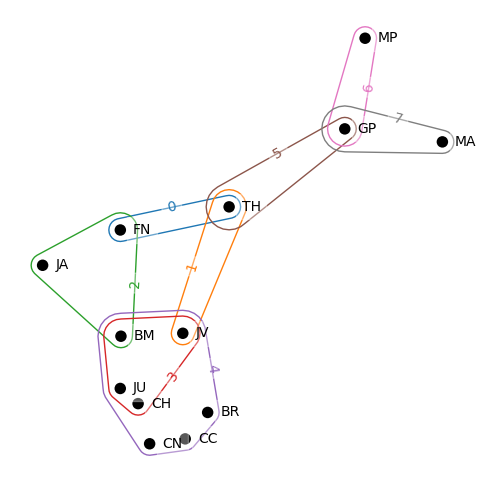

In [26]:
from hypernetx.utils.toys.storylines import create_lesmis_small

H, kwargs = create_lesmis_small()

plt.figure(figsize=(6, 6))
hnx.draw(H)

kwargs

The simplest incidence visualization available in `hypernetx` is based on [UpSet by Lex et al](https://ieeexplore.ieee.org/abstract/document/6876017/). This visualization was designed to visualize set systems in a matrix layout where each row corresponds to a set and each column corresponds to an item. These set systems are equivalent to hypergraphs if we assume hyper edges are sets and nodes are items. We diverge from the UpSet representation slightly by always placing hyper edges on the *x-axis* and hyper nodes on the *y-axis*.

To be consistent with our previous visualization design language, we made the following additional default choices:
* Hyper edges are drawn like *rubber bands* containing their nodes, and assigned a unique color, but
* [**New**] Each node-edge incidence is a filled black circle, and
* [**New**] Incidences for each node are connected by a thin black line

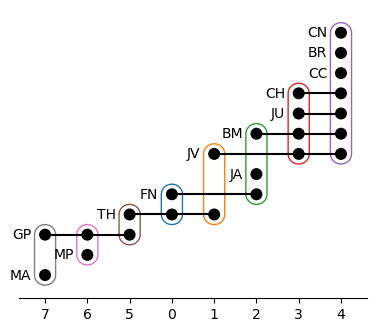

In [3]:
hnx.draw_incidence_upset(H)

## Encoding Data onto Incidences
The example below demonstrates one way to encode information onto a mark representing an incidence. Similar to other `hypernetx.draw*` methods, the `incidences_kwargs` dictionary is used to flexibly transform your data and pass it through to the underlying function that draws the circles. Like the other `*_kwargs` drawing parameters, the keys in the dictionary are valid array arguments for `matplotlib.collection.EllipseCollection`. In this case `facecolor` and `edgecolor` are useful options. The values for this dictionary can be one of:
* List-like: using the canonical incidence order (see below)
* Dict-like: mapping an incidence tuple to a value, e.g. `{(1, "JV"): "pink"}'`
* Function: taking a incidence tuple as input, e.g. `lambda i: "pink" if i == (1, "JV") else "black"`
* Constant, e.g. `"pink"`

The example below demonstrates how to set the `facecolor` of the incidences conditionally, i.e. to *black* if the node is "JV" or the edge is *2*. This is done using the list-like input, which requires iterating over the incidences in the hypergraph in canonical order, i.e. first for each edge and then for each node in that edge. To avoid having to remember the canonical order, use the equivalent dict-like or function inputs.

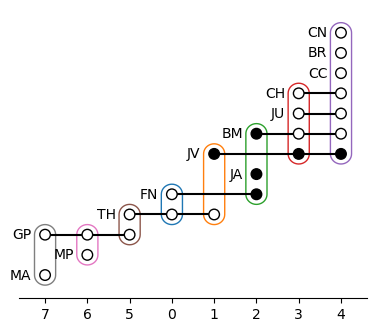

In [4]:
hnx.draw_incidence_upset(
    H,
    incidences_kwargs=dict(
        facecolor=[
            'black' if e == 2 or v == 'JV' else 'white'
            for e in H.edges
            for v in H.edges[e]
        ]
    )
)

For ease of use and compatability with other `hypernetx.draw*` methods, the `nodes_kwargs` parameter is available to be used. In this case `edgecolor` will affect the line drawn between incidences as well as the outline of the incidences themselves.

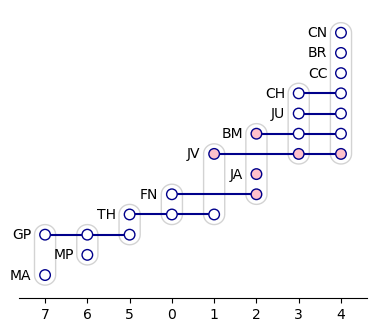

In [5]:
hnx.draw_incidence_upset(
    H,
    edges_kwargs=dict(edgecolor='lightgray'),
    nodes_kwargs=dict(edgecolor='darkblue'),
    incidences_kwargs=dict(
        facecolor=[
            'pink' if e == 2 or v == 'JV' else 'white'
            for e in H.edges
            for v in H.edges[e]
        ]
    )
)

# Ordered Hypergraphs
In the example above, you can see that the hyper edges are drawn "out of order". By default, when no `node_order` or `edge_order` is provided to the function, the drawing algorithm determines an arrangement of the hyper edges and nodes that tends to be more aesthetically pleasing than random. Specifically, we compute a spectral ordering of the bipartite representation of the hypergraph using `networkx.spectral_ordering`. When only one of `node_order` or `edge_order` is provided, the automatic ordering is still computed, but only used for the unspecified ordering. The example below shows several possible combinations of these orders.

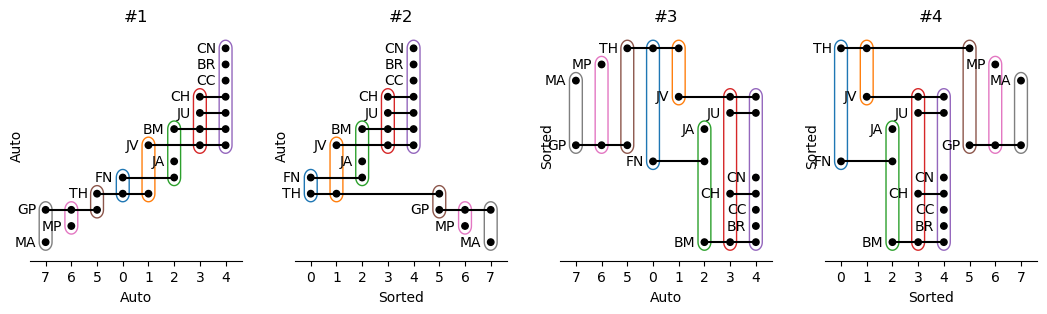

In [6]:
plt.figure(figsize=(13, 3))
i = 1
for no in (None, sorted(H.nodes)):
    for eo in (None, kwargs['edge_order']):
        hnx.draw_incidence_upset(H, edge_order=eo, node_order=no, ax=plt.subplot(1, 4, i), auto_size=False)
        plt.title(f'#{i}')
        plt.xlabel("Auto" if eo is None else "Sorted")
        plt.ylabel("Auto" if no is None else "Sorted")
        i += 1

plt.subplots_adjust(wspace=.25)

# Beyond UpSet: Advanced Visualization Approaches
In the examples above you might have noticed some issues that "clutter" the visualizations, specifically:
* **node-edge crossings** where the line for a node crosses a hyper edge, but that node is not incident to that edge. For example, in #2 the line for *FN* crosses edge *1* but *FN* is not incident to that edge. In #4
* **edge inefficiency** where unneeded whitespace exists within edges. For example, in #3 above, edge *0* has a height of 7 units but only contains two nodes. So there is 5 units of potenially unnecessary whitespace. It is clear that simply re-arranging the nodes, i.e. #1 vs #3, significantly reduces this whitespace (but increases the number of node-edge crossings from 0 to 2).

Thus, there appears to be a tradeoff between these aesthetic proeprties, i.e. crossings can potentialy be reduced at the expense of increasing whitespace. Furthermore, we could relax some of the strict layout assumptions that *UpSet* makes to further reduce clutter. Specifically, we could allow
* Node lines to bend as necessary to avoid edge crossings, or
* Node lines occupy the same y-coordinate at different x-coordinates to reduce edge inefficiency.

To address these challenges, we have developed a storyline visualization approach based on a technique named [SVEN](https://arxiv.org/abs/1412.6706). We discuss this approach below.

## Simple Storyline Visualization
This shows a simple storyline visualization of the same data we have been using throughout the notebook. We used `**kwargs` to correctly sort the edges.

Note that because the dimensions of the visualization are not known until after the layout is found, the `draw_incidence_storyline` function will automatically resize the figure to an approriate aspect ratio. To disable pass `auto_size=False` to this function. To increase the figure size, simply pass `auto_size=2`, for example, which would double the default width and height. Alternatively, you can pass `auto_size=False` to disable this feature and set the figure dimensions yourself.

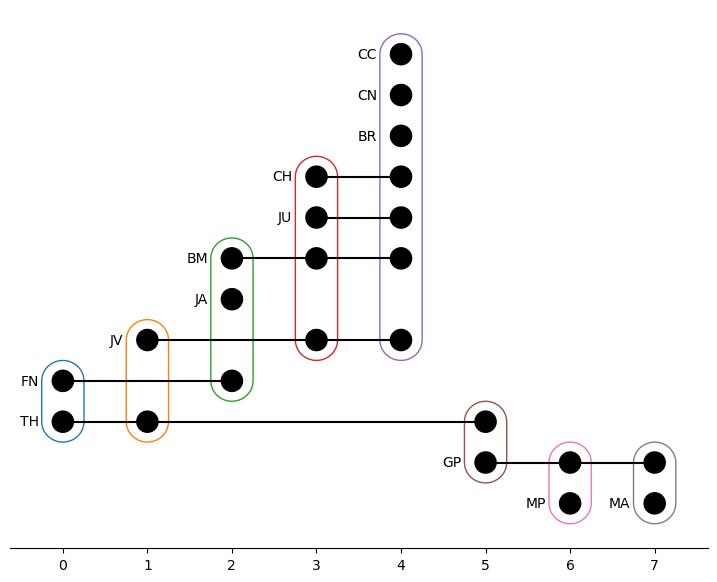

In [27]:
hnx.draw_incidence_storyline(H, auto_size=2, **kwargs)

## Useful layout parameters
The default layout algorithm for storyline visualization is implemented in `hypernetx.drawing.draw_storyline.SvenStoryline`. This algorithm can be sent parameters via the `layout_kwargs` argument in the `hypernetx.draw_incidence_storyline` function. This algorithm relaxes the requirement from *UpSet* where lines must be straight and are drawn on unique y-coordinates. To find an aesthetically pleasing layout under these reduced constraints, the algorithm performs a multi-stage optimization where
1. An ordering of the incidences is found that decreases node crossings, 
2. Node lines are straigtened as much as possible, while preserving the order found previously, and
3. Node lines and hyper edges are compacted as much as possible, while still preserving the order and straightness found previously.

While this layout algorithm is considered experimental, two useful parameters are:
* `allow_node_crossings` which allows the lines for nodes to cross (in the whitespace between hyperedges), and
* `allow_edge_crossings` which allows lines for nodes to cross edges

At least one of these parameters must be `True`, or the algorithm will throw an error.

The example below is better shown using a more complex dataset. For this we are using a representation from an [XKCD storyline comic](https://xkcd.com/657/) as our input hypergraph. This example shows the storyline layout parameterized three different ways. Some statistics about the aesthetic properties are also shown at the bottom of the figure. This quaitifies the tradeoff between node/edge crossings and efficiency. The best parameterization likely depends on the input hypergraph characteristics and user preferences.

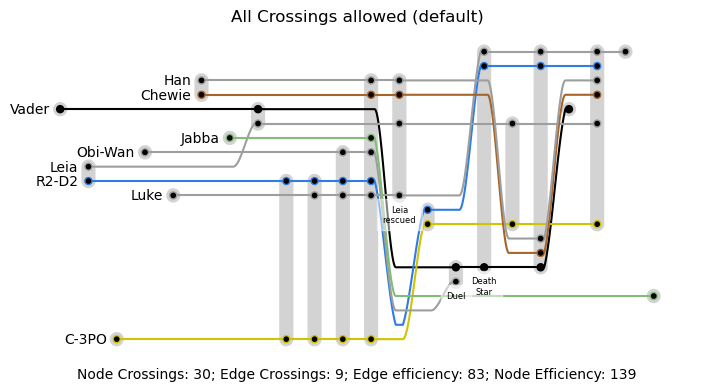

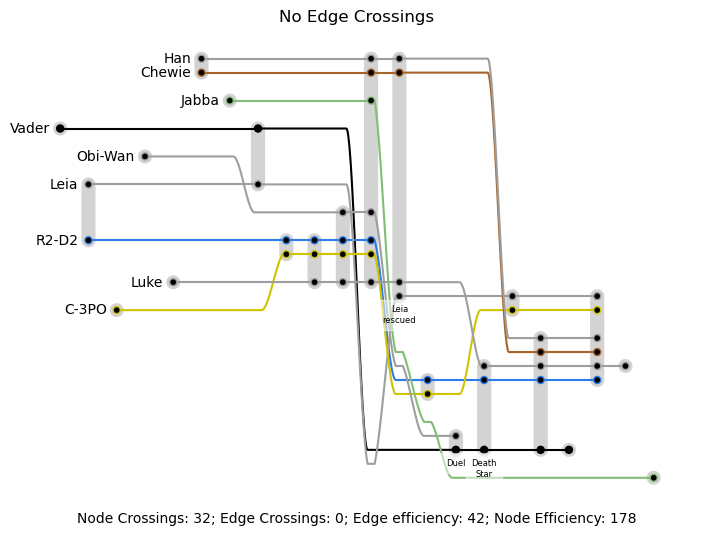

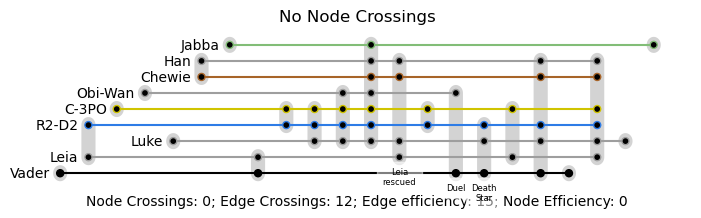

In [48]:
from hypernetx.utils.toys.storylines import create_star_wars

H, kwargs = create_star_wars()
kwargs = dict(
    auto_size=.75,
    edge_labels_on_axis=False,
    edge_labels_kwargs=dict(fontsize=6, backgroundcolor=(1,1,1,.5)),
    **kwargs
)

def draw_storyline_with_stats(H, title=None, **kwargs):
    plt.figure()
    
    layout = hnx.draw_incidence_storyline(H, **kwargs)
    layout.evaluate_aesthetic_criteria()

    plt.title(title)
    plt.xlabel(layout.aesthetic_str)

draw_storyline_with_stats(H, 'All Crossings allowed (default)', **kwargs)
draw_storyline_with_stats(H, 'No Edge Crossings', layout_kwargs=dict(allow_edge_crossings=False), **kwargs)
draw_storyline_with_stats(H, 'No Node Crossings', layout_kwargs=dict(allow_node_crossings=False), **kwargs)

## Storyline visualization with other data